<a href="https://colab.research.google.com/github/riyamotwanii/AML-Assignments/blob/main/Exp-11%20AML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

========== DATASET HEAD ==========

   Age  Income  Browsing_Time  Pages_Viewed  Purchase
0   22   25000              5             3         0
1   25   30000             10             5         0
2   28   35000             15             7         1
3   30   40000             20            10         1
4   35   50000             25            12         1

========== DATASET INFO ==========

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Age            20 non-null     int64
 1   Income         20 non-null     int64
 2   Browsing_Time  20 non-null     int64
 3   Pages_Viewed   20 non-null     int64
 4   Purchase       20 non-null     int64
dtypes: int64(5)
memory usage: 932.0 bytes
None

========== MISSING VALUES ==========

Age              0
Income           0
Browsing_Time    0
Pages_Viewed     0
Purchase         0
dtype: int64

========== 

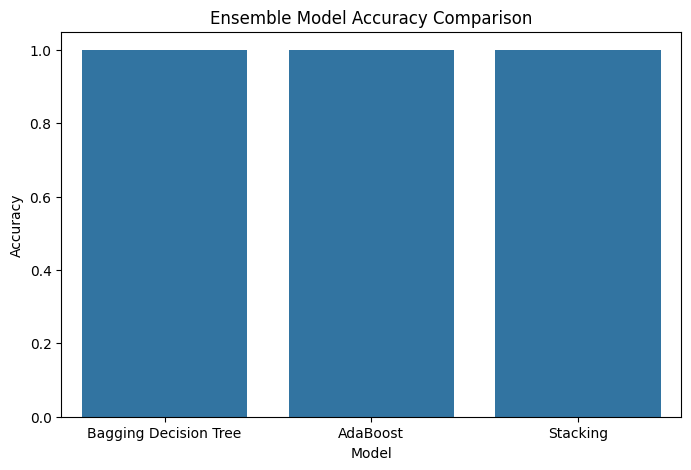


FINAL CONCLUSION

1. Bagging reduced variance using multiple Decision Trees.
2. AdaBoost improved weak learners sequentially.
3. Stacking combined multiple models for better prediction.
4. Ensemble methods improved classification performance.
5. Best model is selected based on highest accuracy.


In [ ]:


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    BaggingClassifier,
    AdaBoostClassifier,
    StackingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

# ============================================================
# STEP 2 : LOAD DATASET
# ============================================================

df = pd.read_csv("customer_purchase_dataset.csv")

print("========== DATASET HEAD ==========\n")
print(df.head())

# ============================================================
# STEP 3 : BASIC INFORMATION
# ============================================================

print("\n========== DATASET INFO ==========\n")
print(df.info())

print("\n========== MISSING VALUES ==========\n")
print(df.isnull().sum())

print("\n========== DATASET SHAPE ==========\n")
print(df.shape)

# ============================================================
# STEP 4 : HANDLE MISSING VALUES
# ============================================================

# Fill numerical columns with mean
for column in df.columns:

    if df[column].dtype != 'object':

        df[column].fillna(
            df[column].mean(),
            inplace=True
        )

# Fill categorical columns with mode
for column in df.columns:

    if df[column].dtype == 'object':

        df[column].fillna(
            df[column].mode()[0],
            inplace=True
        )

# ============================================================
# STEP 5 : ENCODE CATEGORICAL DATA
# ============================================================

encoder = LabelEncoder()

for column in df.columns:

    if df[column].dtype == 'object':

        df[column] = encoder.fit_transform(df[column])

print("\n========== ENCODED DATA ==========\n")
print(df.head())

# ============================================================
# STEP 6 : FEATURES AND TARGET
# ============================================================

# Last column assumed as target
X = df.iloc[:, :-1]

y = df.iloc[:, -1]

# ============================================================
# STEP 7 : FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ============================================================
# STEP 8 : TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# ============================================================
# STEP 9 : BAGGING WITH DECISION TREE
# ============================================================

print("\n================================================")
print("BAGGING WITH DECISION TREE")
print("================================================\n")

bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)

bagging_model.fit(X_train, y_train)

y_pred_bagging = bagging_model.predict(X_test)

# ============================================================
# STEP 10 : ADABOOST CLASSIFIER
# ============================================================

print("\n================================================")
print("ADABOOST CLASSIFIER")
print("================================================\n")

adaboost_model = AdaBoostClassifier(
    n_estimators=50,
    random_state=42
)

adaboost_model.fit(X_train, y_train)

y_pred_adaboost = adaboost_model.predict(X_test)

# ============================================================
# STEP 11 : STACKING CLASSIFIER
# ============================================================

print("\n================================================")
print("STACKING CLASSIFIER")
print("================================================\n")

base_models = [
    ('dt', DecisionTreeClassifier()),
    ('svm', SVC(probability=True)),
    ('lr', LogisticRegression())
]

stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression()
)

stacking_model.fit(X_train, y_train)

y_pred_stacking = stacking_model.predict(X_test)

# ============================================================
# STEP 12 : EVALUATION FUNCTION
# ============================================================

def evaluate_model(y_test, y_pred, model_name):

    print("\n================================================")
    print("MODEL :", model_name)
    print("================================================\n")

    accuracy = accuracy_score(y_test, y_pred)

    print("Accuracy :", round(accuracy * 100, 2), "%")

    print("\nConfusion Matrix :\n")

    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report :\n")

    print(classification_report(y_test, y_pred))

    return accuracy

# ============================================================
# STEP 13 : EVALUATE MODELS
# ============================================================

bagging_accuracy = evaluate_model(
    y_test,
    y_pred_bagging,
    "Bagging Decision Tree"
)

adaboost_accuracy = evaluate_model(
    y_test,
    y_pred_adaboost,
    "AdaBoost Classifier"
)

stacking_accuracy = evaluate_model(
    y_test,
    y_pred_stacking,
    "Stacking Classifier"
)

# ============================================================
# STEP 14 : PERFORMANCE COMPARISON
# ============================================================

comparison = pd.DataFrame({
    'Model': [
        'Bagging Decision Tree',
        'AdaBoost',
        'Stacking'
    ],

    'Accuracy': [
        bagging_accuracy,
        adaboost_accuracy,
        stacking_accuracy
    ]
})

print("\n================================================")
print("MODEL COMPARISON")
print("================================================\n")

print(comparison)

# ============================================================
# STEP 15 : VISUALIZE ACCURACY
# ============================================================

plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison
)

plt.title("Ensemble Model Accuracy Comparison")

plt.show()

# ============================================================
# FINAL CONCLUSION
# ============================================================

print("\n================================================")
print("FINAL CONCLUSION")
print("================================================\n")

print("1. Bagging reduced variance using multiple Decision Trees.")
print("2. AdaBoost improved weak learners sequentially.")
print("3. Stacking combined multiple models for better prediction.")
print("4. Ensemble methods improved classification performance.")
print("5. Best model is selected based on highest accuracy.")